# Module 10 Lab - Unsupervised Learning**Objective:** To understand and apply two common **unsupervised learning** techniques: **K-Means Clustering** for finding groups in data and **Principal Component Analysis (PCA)** for dimensionality reduction.**In this lab, you will write the code to perform clustering and PCA, and you will interpret the results.**

## Part 1: Supervised vs. Unsupervised LearningSo far, every model we have built has been a **supervised learning** model. This means we had **labeled data**—we had both the features (X) and the correct answer, or target (y). The goal was to learn a mapping from X to y.In **unsupervised learning**, we only have the features (X). There is **no target variable**. The goal is to discover interesting structures or patterns hidden in the data on its own.Two major types of unsupervised learning are:*   **Clustering:** Automatically grouping similar data points together.*   **Dimensionality Reduction:** Compressing the data by reducing the number of features while trying to preserve as much information as possible.

## Part 2: K-Means Clustering**Concept:** K-Means is an algorithm that finds a pre-defined number of clusters (`k`) in a dataset. It works by:1.  Randomly placing `k` centroids (the center of a cluster) in the data.2.  **Assignment Step:** Assigning each data point to its nearest centroid.3.  **Update Step:** Moving each centroid to the average position of all the points assigned to it.4.  Repeating steps 2 and 3 until the centroids stop moving.**Problem:** We will use a synthetic dataset of customer spending habits to segment them into groups.

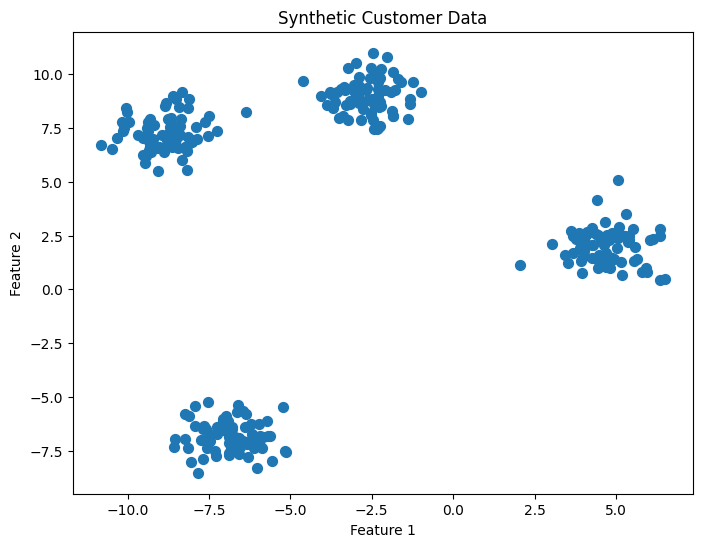

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generate synthetic data
X, y = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.8,
    random_state=42
)

# Visualize the data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Synthetic Customer Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### Task 1: Find the Optimal Number of Clusters (The Elbow Method)**Concept:** How do we know what `k` should be? The **Elbow Method** helps us decide. We run K-Means for a range of `k` values and for each `k`, we calculate the **inertia** (the sum of squared distances of samples to their closest cluster center). We then plot the inertia for each `k`. The "elbow" of the curve—the point where the inertia starts to decrease much more slowly—is a good estimate for the optimal `k`.**Your Task:** Calculate and plot the inertia for `k` values from 1 to 10.

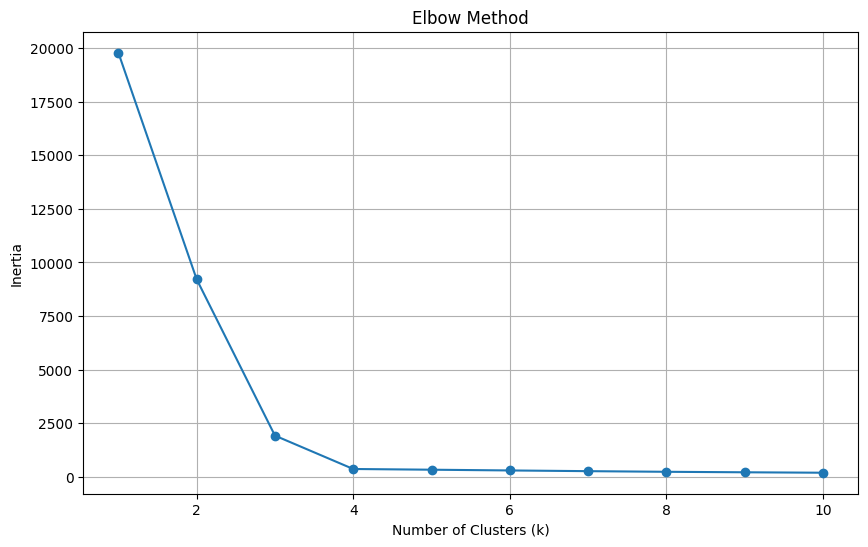

In [3]:
from sklearn.cluster import KMeans

# Store inertia values
inertia = []

# Calculate inertia for k = 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

### Task 2: Perform K-Means Clustering and VisualizeFrom the elbow plot, it looks like `k=4` is the optimal number of clusters.**Your Task:** Run K-Means with `n_clusters=4` and create a scatter plot showing the data points colored by their assigned cluster.

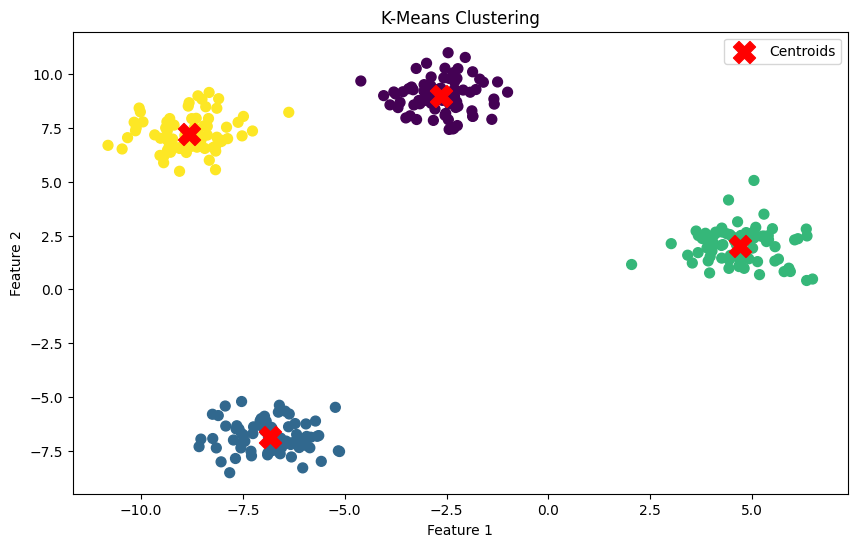

In [4]:
# Create and fit KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X)

# Cluster labels
labels = kmeans.labels_

# Cluster centers
centers = kmeans.cluster_centers_

# Plot clusters
plt.figure(figsize=(10,6))
plt.scatter(X[:,0], X[:,1], c=labels, s=50, cmap="viridis")
plt.scatter(centers[:,0], centers[:,1],
            c="red", marker="X", s=250, label="Centroids")
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

## Part 3: Principal Component Analysis (PCA)**Concept:** PCA is a dimensionality reduction technique. It transforms the data into a new coordinate system of **principal components**. These components are orthogonal (uncorrelated) and are ordered by the amount of variance in the data they explain. By keeping only the first few principal components, we can reduce the number of dimensions in our data while losing as little information as possible.**Use Cases:***   **Visualization:** Reducing high-dimensional data to 2 or 3 dimensions so we can plot it.*   **Performance:** Speeding up model training by using fewer features.**Problem:** We will use the Iris dataset, which has 4 features, and reduce it to 2 features so we can visualize it.

### Task 3: Apply PCA to the Iris Dataset**Your Task:** Use `PCA` from `sklearn.decomposition` to reduce the 4-dimensional Iris dataset to 2 principal components and visualize the result.

Explained variance by component: [0.92461872 0.05306648]
Total variance explained: 0.9776852063187977


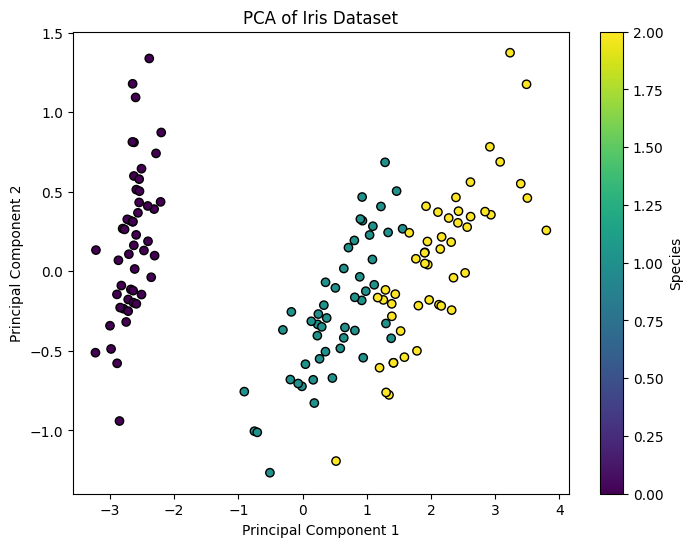

In [6]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

# Load the Iris dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Create PCA model and reduce 4 features to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_iris)

# Print explained variance
print("Explained variance by component:", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())

# Plot the PCA results
plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_iris,
    cmap="viridis",
    edgecolor="k"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Iris Dataset")
plt.colorbar(label="Species")
plt.show()

## 📝 Knowledge Check**Instructions:** Answer the following questions in this markdown cell.

1.  **What is the fundamental difference between supervised and unsupervised learning?**
Supervisor learning uses data that has been labeled with target values that are unknown while unsupervised learning uses unliable data and is attempting to understand and discover hidden patterns and relationships, then grouping them on its own

2.  **In the K-Means elbow plot, why don't we just choose the largest possible `k` to get the lowest inertia?**
We don't use the largest possible value for K because as we increase K inertia will be decreased and too many clusters go overfill the data and create groups that are not meaningful

3.  **In the PCA results, the first two principal components explained over 95% of the variance. What does this tell you about the original 4-dimensional Iris dataset?****
If the first two principl components explain more than 95% of the variance that usually means most of the important day that had information in the original four dimensional data set can be represented in a 2 Dimensional way and it allows the visualization of data with very little loss of information and data at the same time reducing complexity